# BACKTESTER Tuner

### entry_z, exit_z, danger_threshold, ar_limit

### Imports

In [7]:
import os, sys, warnings
import numpy as np
import pandas as pd
import optuna 
import optuna.visualization.matplotlib as ovm
import matplotlib.pyplot as plt
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

warnings.filterwarnings("ignore", category=ValueWarning, module="statsmodels.tsa.base.tsa_model")
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", module="statsmodels.tsa.base.tsa_model")
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from engine import ENGINE
from backtester import BACKTESTER

### Data

In [8]:
synthetic_files = [
    "../data/synthetic/syn_a_ask_202601.parquet",
    "../data/synthetic/syn_a_bid_202601.parquet",
    "../data/synthetic/syn_b_ask_202601.parquet",
    "../data/synthetic/syn_b_bid_202601.parquet"
]
builder = SPREAD(agg_type='volume', threshold=1000, active_hours=(0, 24))
df_synth = builder.build(synthetic_files)

built 575 rows


### Run engine once with optimised block 1 parameters

In [9]:
# 2. RUN ENGINE ONCE WITH OPTIMIZED BLOCK 1 PARAMS
print("Pre-calculating HMM Math (This takes a minute, but only runs once)...")
live_trading_data, _ = ENGINE.walk_forward(
    df=df_synth,
    train_days=5,
    coint_window=300,
    z_window=100,
    k_regimes=3,             # OPTIMIZED: The 3-Regime model
    winsorize_std=5.0,       # OPTIMIZED: Light clipping to prevent panic
    scaling=10000,           # OPTIMIZED: Wide scaling
    print_freq=999
)
print("Math locked. Ready for high-speed Backtester tuning.")

Pre-calculating HMM Math (This takes a minute, but only runs once)...
Running Engine | train_days=5 | coint_window=300 | z_window=100
Math locked. Ready for high-speed Backtester tuning.


### Execution

In [10]:
def objective_execution(trial):
    # --- 1. THE TRADING PARAMETERS TO TUNE ---
    
    # How far must the spread stretch to enter? (1.0 to 2.5 standard deviations)
    entry_z = trial.suggest_float("entry_z", 1.0, 2.5, step=0.1)
    
    # Do we exit early (0.5), at the mean (0.0), or hold for momentum (-0.5)?
    exit_z = trial.suggest_float("exit_z", -0.5, 0.5, step=0.1)
    
    # HMM Filter: If probability of Danger is above this, do not trade.
    danger_threshold = trial.suggest_float("danger_threshold", 0.50, 0.95, step=0.05)
    
    # AR Filter: If the spread is too trendy (approaching random walk), do not trade.
    ar_limit = trial.suggest_float("ar_limit", 0.85, 0.99, step=0.01)

    # --- 2. RUN THE BACKTESTER ---
    # We use the pre-calculated live_trading_data here!
    bt = BACKTESTER(live_trading_data)
    results = bt.run(
        base_z=entry_z, 
        exit_z=exit_z, 
        danger_threshold=danger_threshold,   
        ar_limit=ar_limit,
        fee_bps=0.5, # Static fee
        slippage_mode='half_spread'
    )
    
    # --- 3. CALCULATE THE SCORE ---
    returns = results['Return_MS_AR'].fillna(0)
    
    # Penalize strategies that never trade
    if returns.std() == 0 or (results['Target_MS_AR'] != 0).sum() < 50:
        return -99.0 
        
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252 * 24 * 60)
    return sharpe

### Optimisation

In [11]:
# Create the study and run it for 500 iterations
study_exec = optuna.create_study(direction="maximize", study_name="Execution_Tuning")

print("Starting Execution Optimization...")
study_exec.optimize(objective_execution, n_trials=500, show_progress_bar=True)

print(f"\n=== BEST EXECUTION PARAMETERS ===")
print(f"Best Sharpe Ratio: {study_exec.best_value:.2f}")
for key, value in study_exec.best_params.items():
    print(f"  {key}: {value:.3f}")

Starting Execution Optimization...


  0%|          | 0/500 [00:00<?, ?it/s]


=== BEST EXECUTION PARAMETERS ===
Best Sharpe Ratio: -99.00
  entry_z: 1.400
  exit_z: -0.300
  danger_threshold: 0.650
  ar_limit: 0.990


### Visualising

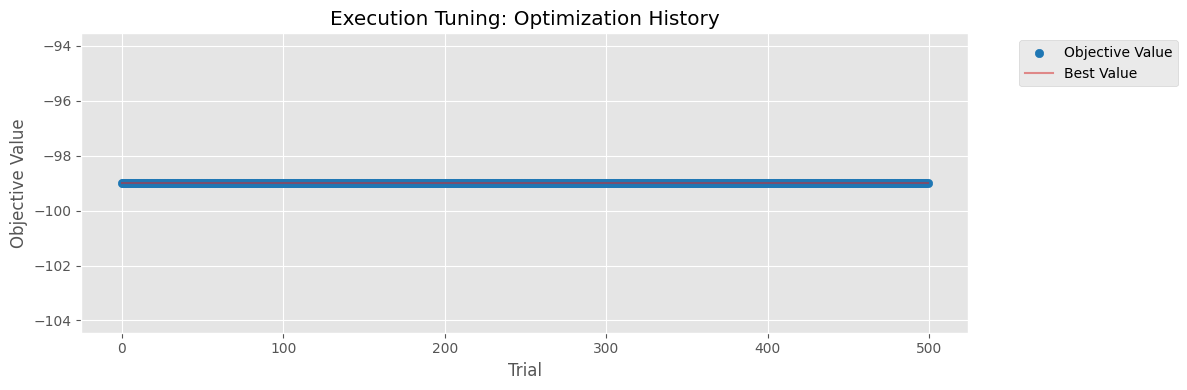

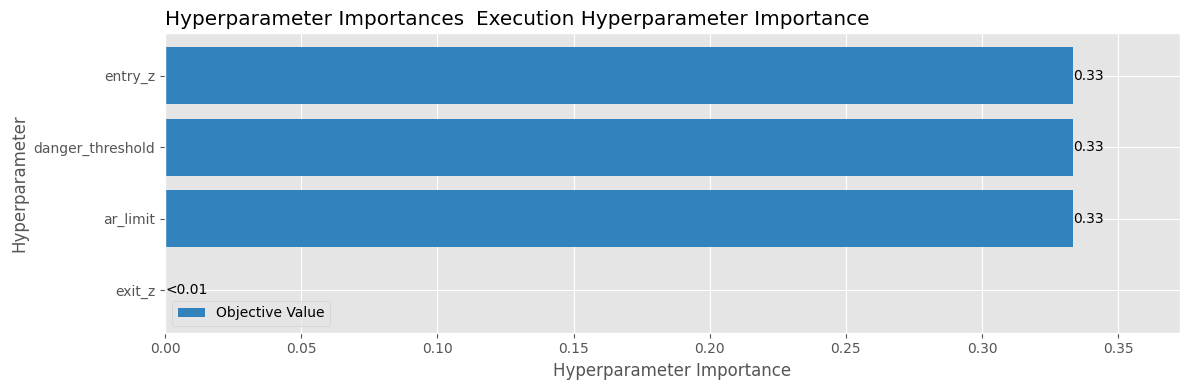

In [12]:
# 1. Plot the optimization history
fig1 = ovm.plot_optimization_history(study_exec)
fig1.figure.set_size_inches(12, 4)
plt.title("Execution Tuning: Optimization History")
plt.tight_layout()
plt.show()

# 2. Plot parameter importances
fig2 = ovm.plot_param_importances(study_exec)
fig2.figure.set_size_inches(12, 4)
plt.title("Execution Hyperparameter Importance")
plt.tight_layout()
plt.show()